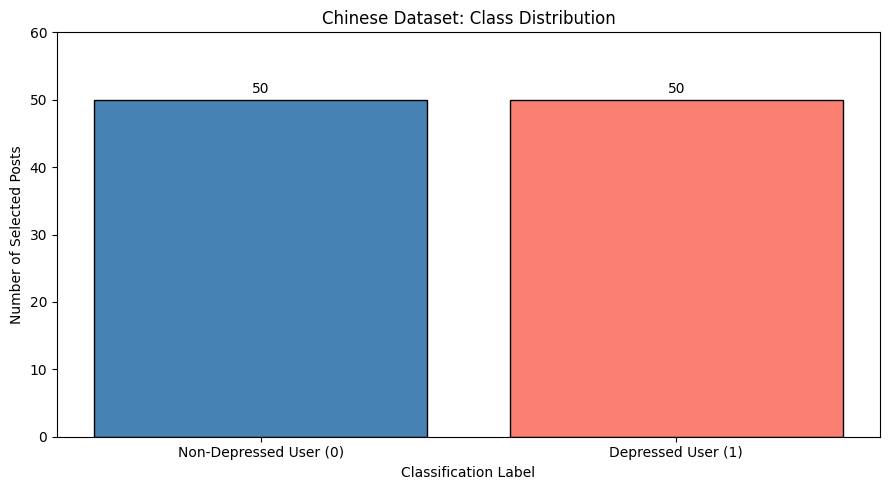

In [4]:

#Visualization 1: Chinese Class Distribution

import pandas as pd
import matplotlib.pyplot as plt

#Loads the selected Chinese sample with 100 posts
df = pd.read_csv("chinese_sample_split.csv")

#Counts the number of posts in each class
counts = df["label"].value_counts().reindex([0, 1], fill_value=0)

#Creates the bar chart
plt.figure(figsize=(9, 5))

#Creates bar chart and assigns colours to the classification labels
bars = plt.bar(
    ["Non-Depressed User (0)", "Depressed User (1)"],
    counts.values,
    color=["steelblue", "salmon"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Chinese Dataset: Class Distribution")
plt.xlabel("Classification Label")
plt.ylabel("Number of Selected Posts")

#Displays numbers above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha="center"
    )

plt.ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.show()


**Figure 1: Chinese Dataset Class Distribution**

Figure 1 shows the distribution of the classification labels in the selected Chinese dataset. This sample has 100 posts, with 50 posts from depressed users and 50 posts from non-depressed users. This balanced distribution was intentionally created during preprocessing to ensure equal representation of both classes in the experiment. Unlike the Arabic and Thai datasets, the Chinese labels are assigned at the user level rather than independently to each post. Therefore, the graph shows an equal distribution of selected posts from both user categories, rather than indicating how frequently depression-related content appears across individual posts.

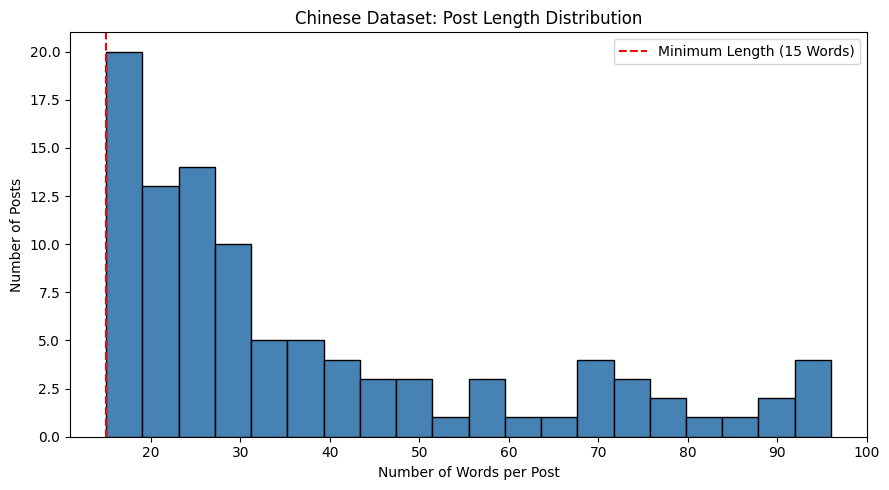

Post Length Statistics:
count    100.000000
mean      38.120000
std       22.657431
min       15.000000
25%       22.000000
50%       29.000000
75%       49.250000
max       96.000000
Name: n_words, dtype: float64


In [5]:

#Visualization 2: Chinese Post Length Distribution

#Sets the figure size of the histogram
plt.figure(figsize=(9, 5))

#Creates the histogram, sets the number of bins, and assigns colours
plt.hist(
    df["n_words"],
    bins=20,
    color="steelblue",
    edgecolor="black"
)

#Shows the minimum word requirement
plt.axvline(
    x=15,
    color="red",
    linestyle="--",
    label="Minimum Length (15 Words)"
)

#Adding labels and a title
plt.title("Chinese Dataset: Post Length Distribution")
plt.xlabel("Number of Words per Post")
plt.ylabel("Number of Posts")

plt.legend()
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Post Length Statistics:")
print(df["n_words"].describe())


**Figure 2: Chinese Post Length Distribution**

Figure 2 shows the distribution of post lengths in the selected Chinese dataset, measured by the number of words per post. The 100 selected posts have an average length of approximately 38.1 words and a median of 29 words, with lengths ranging from 15 to 96 words. The difference between the mean and median suggests that some longer posts increase the overall average. Since Chinese does not consistently use spaces to separate words, jieba was used during preprocessing to calculate word counts. The minimum length requirement of 15 words ensures that each post contains enough text to be meaningfully divided into three sections for the project's experiments.

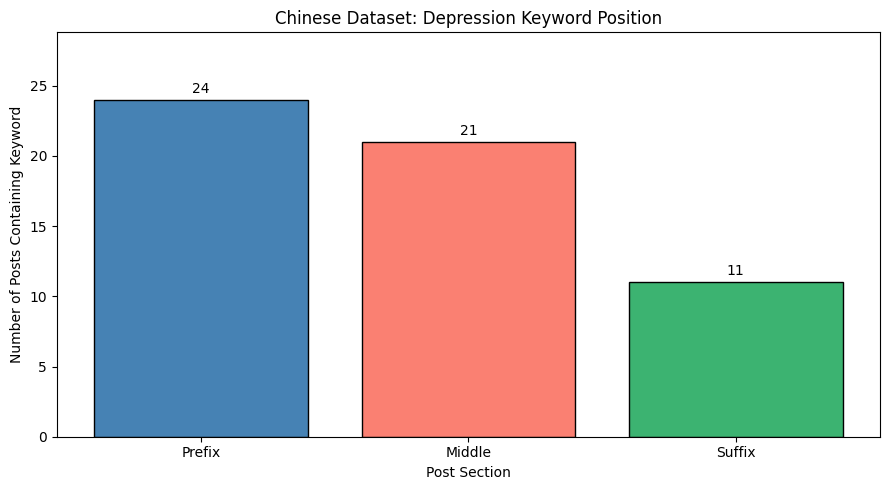

Keyword Position Distribution:
kw_in_prefix    24
kw_in_middle    21
kw_in_suffix    11
dtype: int64


In [6]:

#Visualization 3: Chinese Depression Keyword Position

#Takes posts with the depression keyword
keyword_posts = df[df["has_keyword"] == True]

#Counts the number of times the keyword is used per section
position_counts = keyword_posts[
    ["kw_in_prefix", "kw_in_middle", "kw_in_suffix"]
].sum()

#Creates the bar chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    ["Prefix", "Middle", "Suffix"],
    position_counts.values,
    color=["steelblue", "salmon", "mediumseagreen"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Chinese Dataset: Depression Keyword Position")
plt.xlabel("Post Section")
plt.ylabel("Number of Posts Containing Keyword")

#Displays values above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha="center"
    )

plt.ylim(0, max(position_counts.values) * 1.2)
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Keyword Position Distribution:")
print(position_counts)


**Figure 3: Chinese Depression Keyword Position Distribution**

Figure 3 shows where the Chinese depression keyword (抑郁) appears within the 50 selected posts containing the keyword. The keyword appears in the prefix of 24 posts, the middle of 21 posts, and the suffix of 11 posts. Some posts contain the keyword in multiple sections, so the total exceeds 50. The results indicate that the keyword appears most frequently near the beginning of the selected posts. This is relevant to the project's text splitting experiments because a model receiving only one section of a post may have access to different information depending on the keyword's position.

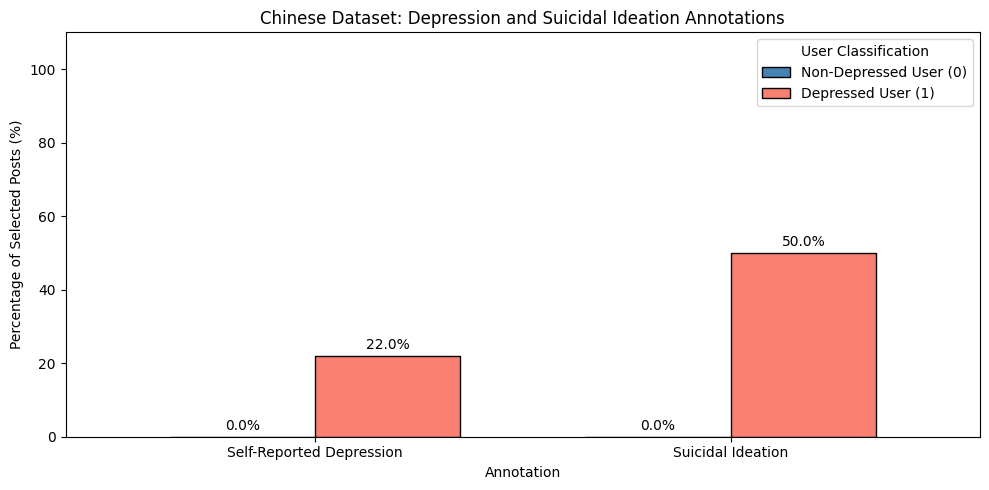

Annotation Distribution (%):
                          Non-Depressed User (0)  Depressed User (1)
Self-Reported Depression                     0.0                22.0
Suicidal Ideation                            0.0                50.0


In [7]:

#Visualization 4: Self-Reported Depression and Suicidal Ideation

#Selects the two annotation columns
annotation_columns = [
    "self_reported",
    "suicidal_ideation"
]

#Calculates the percentage of posts with each annotation by label
annotation_percentages = (
    df.groupby("label")[annotation_columns].mean() * 100
)

#Renames the classification labels
annotation_percentages.index = [
    "Non-Depressed User (0)",
    "Depressed User (1)"
]

#Renames the annotation labels
annotation_percentages.columns = [
    "Self-Reported Depression",
    "Suicidal Ideation"
]

#Swaps rows and columns to compare both classification labels by annotation
annotation_percentages = annotation_percentages.T

#Creates a grouped bar chart
ax = annotation_percentages.plot(
    kind="bar",
    figsize=(10, 5),
    color=["steelblue", "salmon"],
    edgecolor="black",
    width=0.7
)

#Adding labels and a title
plt.title("Chinese Dataset: Depression and Suicidal Ideation Annotations")
plt.xlabel("Annotation")
plt.ylabel("Percentage of Selected Posts (%)")

plt.xticks(rotation=0)
plt.legend(title="User Classification")

#Displays percentages above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Annotation Distribution (%):")
print(annotation_percentages.round(1))


**Figure 4: Chinese Self-Reported Depression and Suicidal Ideation**

Figure 4 compares the presence of self-reported depression and suicidal ideation annotations across the two classification labels in the selected Chinese dataset. Among posts from depressed users, 22% contain the self-reported depression annotation, while 50% contain the suicidal ideation annotation. Neither annotation is present in the selected posts from non-depressed users. These differences provide additional insight into the content of the selected posts.